#Bibliotecas usadas

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow

#Fazendo o upload da imagem

In [ ]:
uploads = files.upload()

Saving images.jpg to images.jpg


#Testando a imagem


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
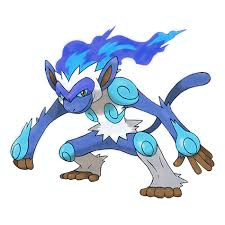

In [ ]:
img = cv2.imread('images.jpg')
img

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
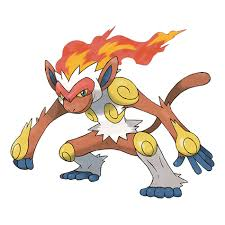

In [ ]:
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img_rgb

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
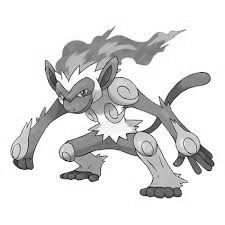

In [ ]:
img_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img_gray

#Criando a função para fazer os calculos de bit

Esse if foi criado porque estava sendo criado um fundo atras da imagem e ela não estava indo aos extremos de 255 de branco e preto,ia por volta da escala 185, com esse if ela vai faz a verificação para identificar se precisar ir até o limite da escala ou não

In [ ]:
def quantizar(img_gray, bits):
    niveis = 2 ** bits #Calcula quantos tons de cinza a imagem final terá de acordo com a entrada de bits
    fator = 256 // niveis #Calcula o onde as cores originais serão agrupadas., ou seja vai de onde até onde a cor
    idx = img_gray // fator #divide o valor original de cada pixel pelo fator
    escala = 255 // (niveis - 1) if niveis > 1 else 255 #Calcula de quanto em quanto os novos tons devem saltar para que a imagem final continue ocupando toda a escala de 0 a 255
    img_quant = idx * escala #Pega os índices gerados e os multiplica pela escala
    return img_quant.astype(np.uint8)

Usando a função para fazer as mudanças na imagem

In [ ]:
img_1bit = quantizar(img_gray,1)

img_2bit = quantizar(img_gray,2)


img_4bit = quantizar(img_gray,4)


img_8bit = quantizar(img_gray,8)

#Plotando as imagens mudadas

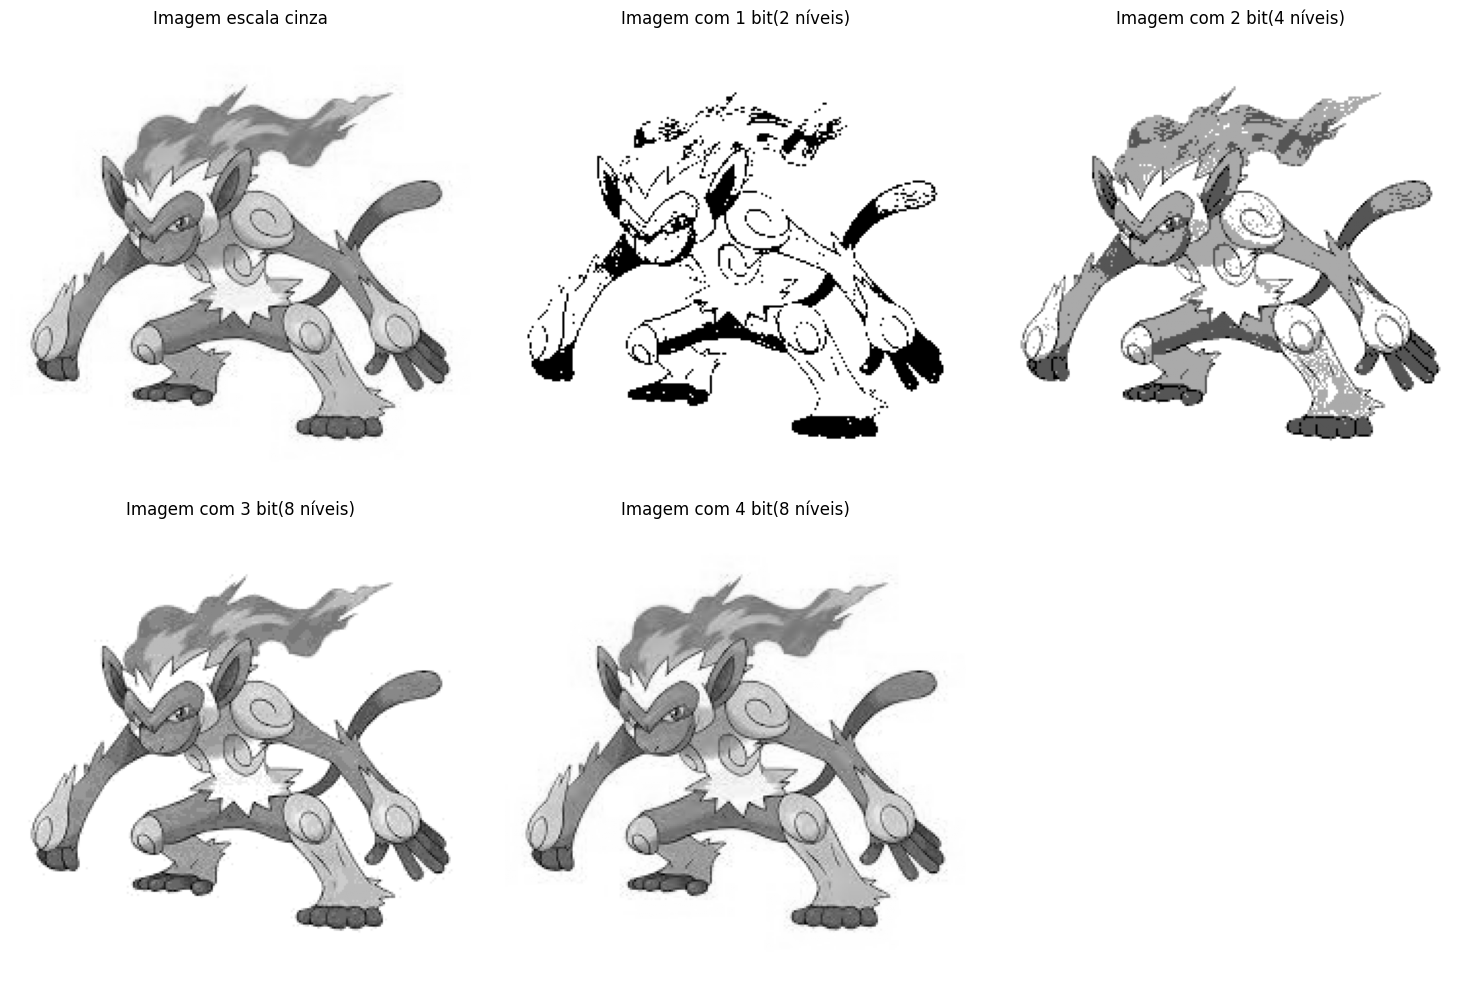

In [ ]:
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.title('Imagem escala cinza')
plt.imshow(img_gray, cmap= 'gray')
plt.axis('off')

plt.subplot(2,3,2)
plt.title('Imagem com 1 bit(2 níveis)')
plt.imshow(img_1bit, cmap= 'gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.title('Imagem com 2 bit(4 níveis)')
plt.imshow(img_2bit, cmap= 'gray')
plt.axis('off')

plt.subplot(2,3,4)
plt.title('Imagem com 3 bit(8 níveis)')
plt.imshow(img_4bit, cmap= 'gray')
plt.axis('off')

plt.subplot(2,3,5)
plt.title('Imagem com 4 bit(8 níveis)')
plt.imshow(img_8bit, cmap= 'gray')
plt.axis('off')

plt.savefig('quantização.Entrega.png')
plt.tight_layout()